In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Understanding and Implementing Dirichlet Boundary Conditions

## What are Dirichlet Boundary Conditions?

Dirichlet boundary conditions define the **exact value of the solution at the boundaries** of the computational domain.

For a one-dimensional domain:


A Dirichlet boundary condition specifies:

\[
u(0,t)=u_{left}
\]

\[
u(L,t)=u_{right}
\]

This means that the solution value at the left and right boundaries is **fixed and remains unchanged during the simulation**.

---

# Key Concept in Finite Difference Methods

In a finite difference discretisation, the computational domain consists of:

- **Interior nodes** → values are calculated using the governing equation.
- **Boundary nodes** → values are directly assigned from the boundary conditions.

The finite difference update equation is applied **only to interior nodes**.

For a domain with \(N\) grid points:

\[
u_0^{n+1}=u_{left}
\]

\[
u_{N-1}^{n+1}=u_{right}
\]

where:

- \(u_0\) is the left boundary node.
- \(u_{N-1}\) is the right boundary node.
- \(n+1\) represents the new time step.

---

# Example: Homogeneous Dirichlet Boundary Conditions

For fixed zero-value boundaries:

\[
u(0,t)=0
\]

\[
u(L,t)=0
\]

the boundary values are enforced after every time update:

```python
unew[0]  = 0      # Left boundary condition
unew[-1] = 0      # Right boundary condition

In [40]:
nx=21
L=1.0
dx=L/(nx-1)
x=np.linspace(0.0,L,nx)


In [41]:
tend=1.0
t=0
mu=0.05
c=1.0
dt=0.001
fo=dt*mu/dx**2
co=c*dt/dx
om=2*np.pi
u0= lambda x:np.sin(om*x)


In [42]:
u=np.zeros(nx)
u=u0(x)


# FTCS Scheme: Defining Dirichlet Boundary Conditions

u[0]=0


u[-1]=0


In [43]:
sol=[]

while t< tend:
 unew=np.zeros(nx)
 for i in range  (1,nx-1):
  unew[i]=u[i]-co*(u[i]-u[i-1])+fo*(u[i+1]-2*u[i]+u[i-1])
 unew[0]=0
 unew[-1]=0
 u[:]=unew[:]
 sol.append(unew)
 t+=dt

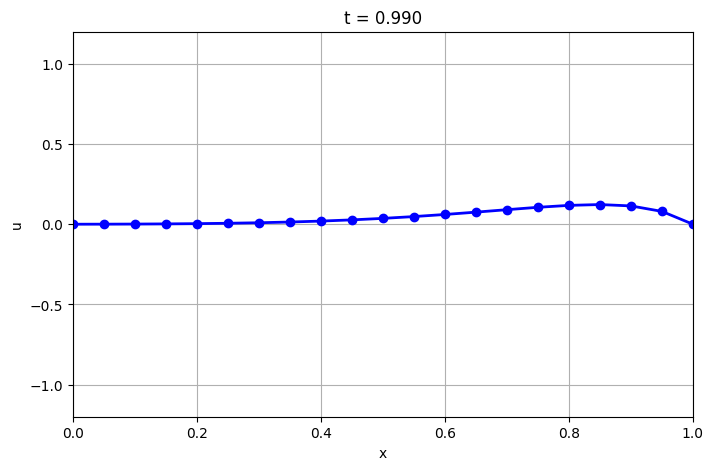

In [44]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8,5))

line, = ax.plot([], [], 'bo-', lw=2)

ax.set_xlim(0, L)
ax.set_ylim(-1.2, 1.2)

ax.set_xlabel('x')
ax.set_ylabel('u')
ax.grid(True)

def init():
    line.set_data([], [])
    return line,

def animate(frame):

    line.set_data(x, sol[frame])

    ax.set_title(f"t = {frame*dt:.3f}")

    return line,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=range(0, len(sol), 10),
    init_func=init,
    interval=100,
    blit=True
)

HTML(ani.to_jshtml())